# Detecting Anomalous Transactions
Unsupervised anomaly detection on the Kaggle credit card fraud dataset, using Isolation Forest and Local Outlier Factor (LOF) to flag potentially fraudulent transactions without relying on labels during training.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv


## Load & Inspect the Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

## Data Cleaning
Checking for duplicate rows and missing values before any analysis.

In [7]:
df.duplicated().sum()

np.int64(1081)

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(283726, 31)

In [11]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

# Exploratory Data Analysis

## Amount Analysis

In [13]:
df['Amount'].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

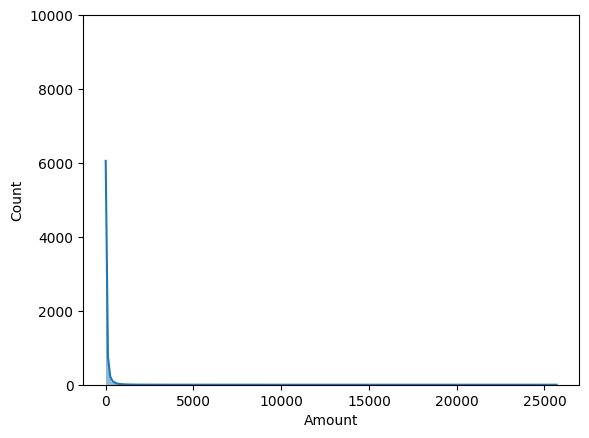

In [15]:
sns.histplot(df['Amount'], kde=True)

plt.ylim(0, 10000)

plt.show()

*The data is heavily skewed to the right.*

## Time Analysis

In [16]:
df['Time'].min()

0.0

In [17]:
df['Time'].max()

172792.0

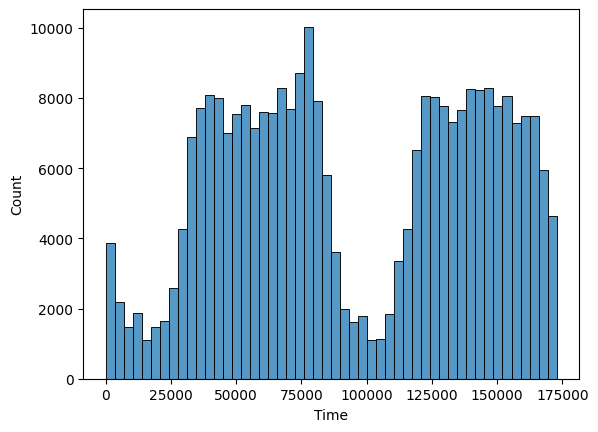

In [18]:
sns.histplot(df['Time'], bins=50)

plt.show()

*Transaction volume shows a clear cyclical pattern, consistent with two days of activity and lower volume overnight.*

## Class Analysis

In [19]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [20]:
df['Class'].value_counts(normalize=True)*100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

*The dataset is heavily imbalanced — fraudulent transactions make up a very small fraction of all transactions, which motivates an anomaly-detection approach over standard classification.*

## Feature Inspection & Transformation

In [21]:
#Feature Selection
df.columns.drop('Class')

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

In [22]:
df.describe().drop('Class', axis=1)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,0.000187,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.769984,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-54.497720,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.211469,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.062353,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.133207,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,39.420904,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000


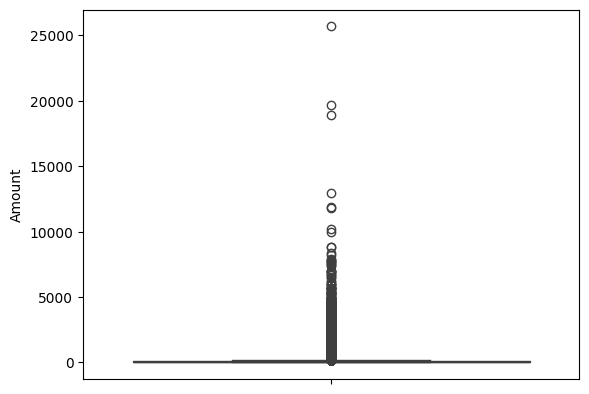

In [23]:
#Visualization
sns.boxplot(df['Amount'])

plt.show()

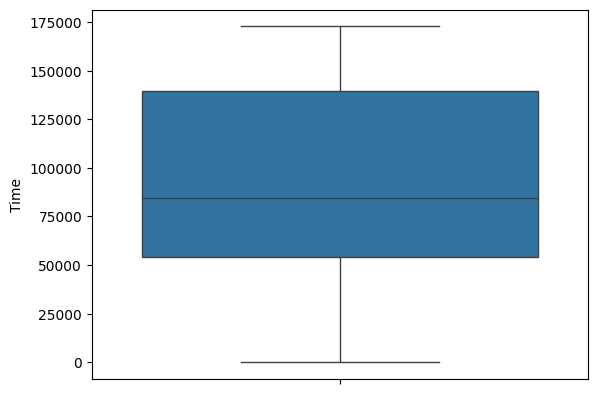

In [24]:
#Visualization
sns.boxplot(df['Time'])

plt.show()

### Log-transforming Amount

In [25]:
df['Amount_log'] = np.log(1 + df['Amount'])

In [26]:
df['Amount_log'].describe()

count    283726.000000
mean          3.153760
std           1.657080
min           0.000000
25%           1.887070
50%           3.135494
75%           4.363226
max          10.153941
Name: Amount_log, dtype: float64

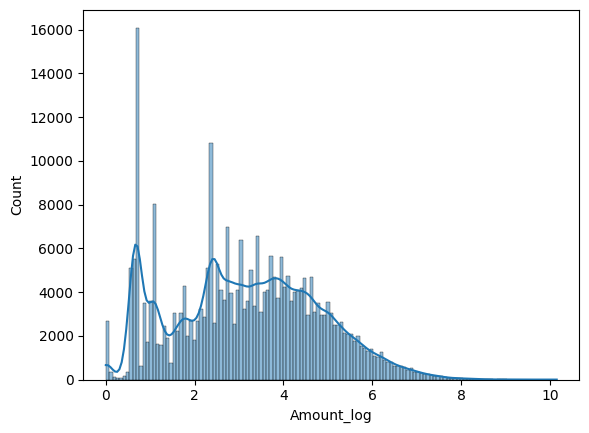

In [27]:
sns.histplot(df['Amount_log'], kde=True)

plt.show()

### Post-transformation Sanity Check
Re-checking for nulls and duplicates after adding `Amount_log`, and reviewing rows that are now duplicates when `Class` is excluded.

In [28]:
df.isnull().sum().sum()

np.int64(0)

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
duplicates = df[df.drop(columns='Class').duplicated(keep=False)]
duplicates.sort_values(by=list(df.drop(columns='Class').columns))

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log


In [31]:
df.shape

(283726, 32)

## Anomaly Detection: Isolation Forest

### Isolation Forest

In [32]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

In [33]:
X = df.drop(columns='Amount')

In [34]:
model = IsolationForest(contamination=0.0017, random_state=42)

df['anomaly'] = model.fit_predict(X)

In [35]:
df['anomaly'].value_counts()

anomaly
 1    283243
-1       483
Name: count, dtype: int64

In [36]:
anomaly= df[df['anomaly'] == -1][['Time', 'Amount', 'Amount_log']]

In [37]:
anomaly.describe()

,Time,Amount,Amount_log
count,483.000000,483.000000,483.000000
mean,84018.124224,1175.363478,4.629360
std,49265.997204,2659.126437,2.722964
min,1264.000000,0.000000,0.000000
25%,41142.500000,8.835000,2.285751
50%,76826.000000,102.000000,4.634729
75%,131403.000000,891.000000,6.793189
max,172778.000000,25691.160000,10.153941


In [38]:
pd.crosstab(
    df['anomaly'],
    df['Class']
)

Class,0,1
anomaly,,
-1,351,132
1,282902,341


In [39]:
print(classification_report(
    df['Class'],
    df['anomaly'].map({1: 0, -1: 1})
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    283253
           1       0.27      0.28      0.28       473

    accuracy                           1.00    283726
   macro avg       0.64      0.64      0.64    283726
weighted avg       1.00      1.00      1.00    283726



*Treating Isolation Forest's flagged anomalies as fraud predictions gives a first read on precision/recall against the true `Class` labels.*

### Anomaly Scores

In [40]:
df['anomaly_score'] = model.decision_function(X)

In [41]:
df[df['Class'] == 1][['anomaly_score', 'anomaly']].sort_values('anomaly_score')

,anomaly_score,anomaly
154684,-0.096835,-1
154587,-0.091020,-1
151006,-0.086344,-1
154371,-0.083915,-1
43428,-0.078880,-1
...,...,...
56703,0.262039,1
219025,0.263892,1
58761,0.264091,1
68633,0.274328,1


In [42]:
df.groupby(['Class', 'anomaly'])['Amount'].agg(['count', 'mean', 'median'])

count         mean  median
Class anomaly                             
0     -1          351  1575.321368  274.00
       1       282902    86.568750   22.00
1     -1          132   111.839091   34.56
       1          341   128.529707    7.57

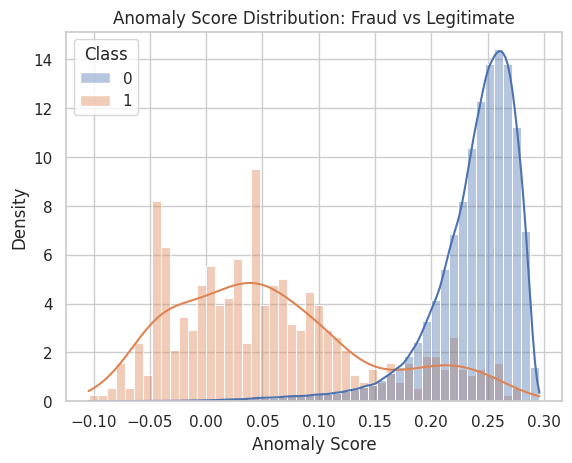

In [43]:
sns.set_theme(style="whitegrid")

sns.histplot(
    data=df,
    x="anomaly_score",
    hue="Class",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False,
    alpha=0.4
)

plt.title("Anomaly Score Distribution: Fraud vs Legitimate")
plt.xlabel("Anomaly Score")
plt.ylabel("Density")
plt.show()

## Anomaly Detection: Local Outlier Factor (LOF)

### Local Outlier Factor

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

In [45]:
features = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount_log']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[features])

In [46]:
X_scaled.shape

(283726, 30)

In [47]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.0017
)

In [48]:
lof_labels = lof.fit_predict(X_scaled)

In [49]:
pd.Series(lof_labels).value_counts()

 1    283243
-1       483
Name: count, dtype: int64

In [50]:
df['lof'] = lof_labels

In [51]:
pd.crosstab(
    df['anomaly'], 
    df['lof']
)

lof,-1,1
anomaly,,
-1,6,477
1,477,282766


In [52]:
pd.crosstab(
    df['Class'], 
    df['lof']
)

lof,-1,1
Class,,
0,482,282771
1,1,472


In [53]:
df['lof_score'] = lof.negative_outlier_factor_

In [54]:
df[['lof_score', 'Class', 'lof']].sort_values('lof_score').head(10)

,lof_score,Class,lof
160461,-2858.019032,0,-1
139314,-2644.949042,0,-1
22552,-1844.281003,0,-1
73202,-1709.520645,0,-1
242877,-1672.723599,0,-1
3596,-1614.137299,0,-1
27135,-1583.755253,0,-1
3501,-1572.253889,0,-1
102200,-1570.042737,0,-1
3575,-1449.066408,0,-1


In [55]:
df.groupby('Class')['lof_score'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,-1.309572,14.39623,-2858.019032,-1.197507,-1.083530,-1.018748,-0.885202
1,473.0,-1.188581,0.30109,-3.385139,-1.232625,-1.077674,-1.016978,-0.954146


*LOF identified locally unusual transactions, but these anomalies showed little overlap with the actual fraud labels. Fraud and legitimate transactions had similar typical LOF scores, while several legitimate transactions had extremely low LOF scores.*

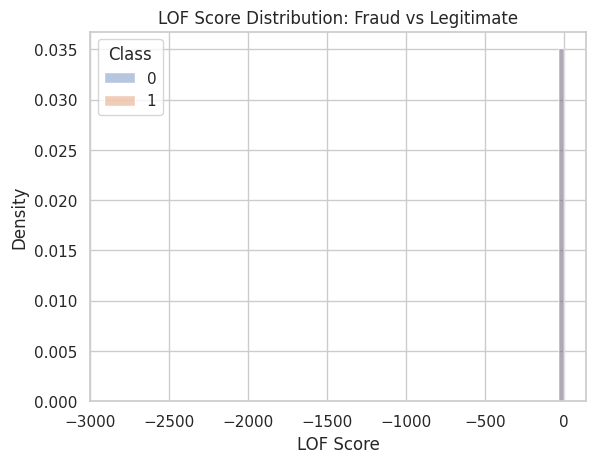

In [56]:
sns.set_theme(style="whitegrid")

sns.histplot(
    data=df,
    x="lof_score",
    hue="Class",
    bins=100,
    stat="density",
    common_norm=False,
    alpha=0.4
)

plt.title("LOF Score Distribution: Fraud vs Legitimate")
plt.xlabel("LOF Score")
plt.ylabel("Density")
plt.show()

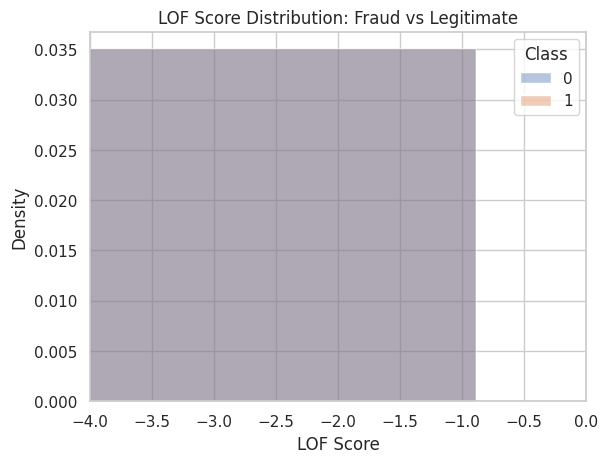

In [57]:
sns.set_theme(style="whitegrid")

sns.histplot(
    data=df,
    x="lof_score",
    hue="Class",
    bins=100,
    stat="density",
    common_norm=False,
    alpha=0.4
)

plt.title("LOF Score Distribution: Fraud vs Legitimate")
plt.xlabel("LOF Score")
plt.ylabel("Density")
plt.xlim(-4, 0)
plt.show()

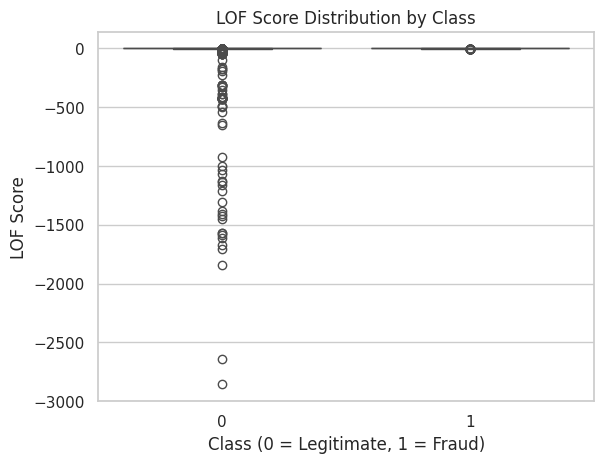

In [58]:
sns.boxplot(
    data=df,
    x="Class",
    y="lof_score"
)

plt.title("LOF Score Distribution by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("LOF Score")
plt.show()

In [59]:
pd.crosstab(df['Class'], df['lof'])

lof,-1,1
Class,,
0,482,282771
1,1,472


*LOF detected transactions that were locally unusual, but those local outliers had almost no overlap with the actual fraud cases.*

## Comparing Isolation Forest vs. LOF
Precision, recall, and F1-score for both models against the true fraud labels, plus confusion matrices.

In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [61]:
# -1 = anomaly/fraud prediction, 1 = normal
if_pred = (df['anomaly'] == -1).astype(int)
lof_pred = (df['lof'] == -1).astype(int)

# Actual labels
y_true = df['Class']

# Isolation Forest
if_precision = precision_score(y_true, if_pred)
if_recall = recall_score(y_true, if_pred)
if_f1 = f1_score(y_true, if_pred)

# LOF
lof_precision = precision_score(y_true, lof_pred)
lof_recall = recall_score(y_true, lof_pred)
lof_f1 = f1_score(y_true, lof_pred)

print("Isolation Forest")
print("Precision:", if_precision)
print("Recall:", if_recall)
print("F1-score:", if_f1)

print("\nLOF")
print("Precision:", lof_precision)
print("Recall:", lof_recall)
print("F1-score:", lof_f1)

Isolation Forest
Precision: 0.2732919254658385
Recall: 0.27906976744186046
F1-score: 0.27615062761506276

LOF
Precision: 0.002070393374741201
Recall: 0.0021141649048625794
F1-score: 0.0020920502092050207


In [62]:
comparison = pd.DataFrame({
    'Model': ['Isolation Forest', 'LOF'],
    'Precision': [if_precision, lof_precision],
    'Recall': [if_recall, lof_recall],
    'F1-score': [if_f1, lof_f1]
})

comparison

,Model,Precision,Recall,F1-score
0,Isolation Forest,0.273292,0.279070,0.276151
1,LOF,0.002070,0.002114,0.002092


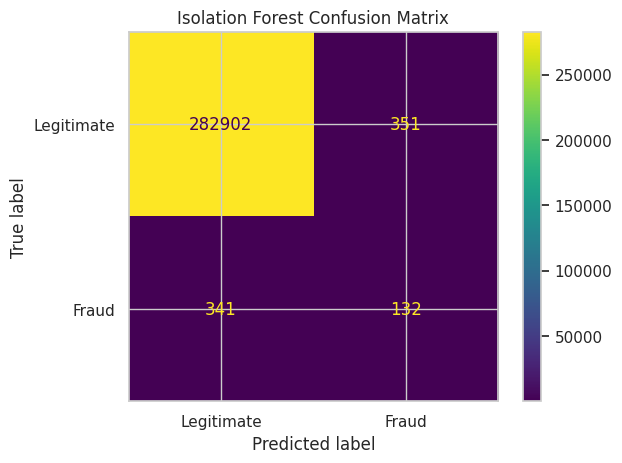

In [63]:
# Isolation Forest
cm_if = confusion_matrix(y_true, if_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm_if,
    display_labels=['Legitimate', 'Fraud']
).plot()

plt.title("Isolation Forest Confusion Matrix")
plt.show()

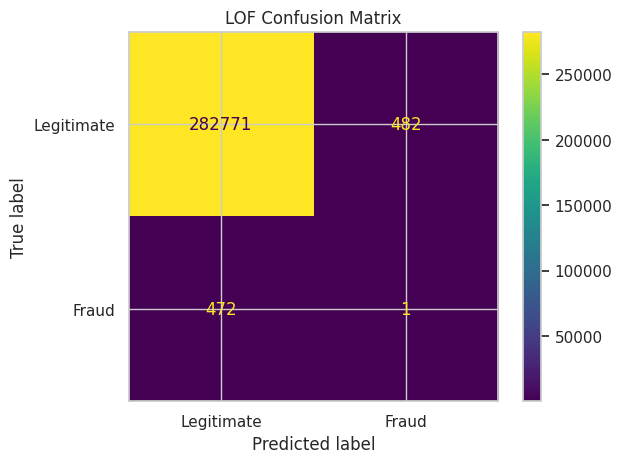

In [64]:
cm_lof = confusion_matrix(y_true, lof_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lof,
    display_labels=['Legitimate', 'Fraud']
).plot()

plt.title("LOF Confusion Matrix")
plt.show()

*Isolation Forest showed substantially greater alignment with the known fraud labels than LOF, achieving 27.3% precision, 27.9% recall, and a 27.6% F1-score, while LOF achieved only 0.21% across all three metrics.*

### Score Distributions for Known Fraud Cases

In [65]:
df[df['Class'] == 1][['anomaly_score', 'lof_score']].describe()

,anomaly_score,lof_score
count,473.000000,473.000000
mean,0.058281,-1.188581
std,0.086093,0.301090
min,-0.096835,-3.385139
25%,-0.004425,-1.232625
50%,0.044582,-1.077674
75%,0.103289,-1.016978
max,0.276784,-0.954146


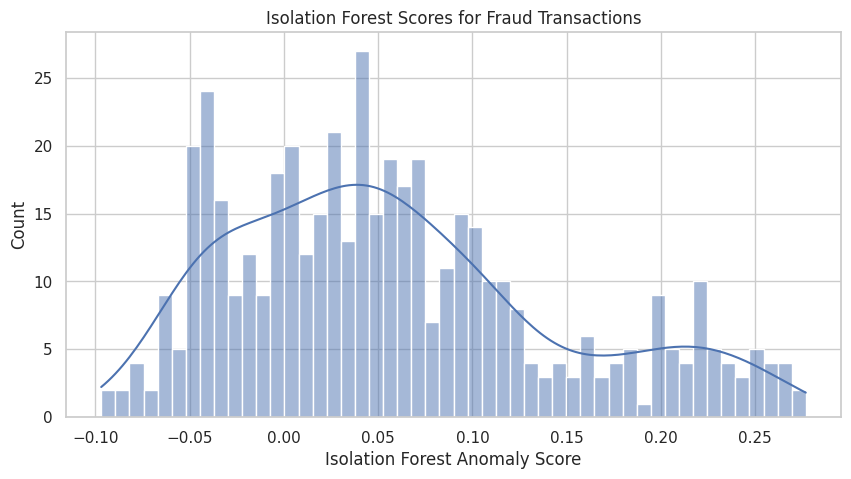

In [66]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df[df['Class'] == 1],
    x='anomaly_score',
    bins=50,
    kde=True
)

plt.title("Isolation Forest Scores for Fraud Transactions")
plt.xlabel("Isolation Forest Anomaly Score")
plt.ylabel("Count")
plt.show()

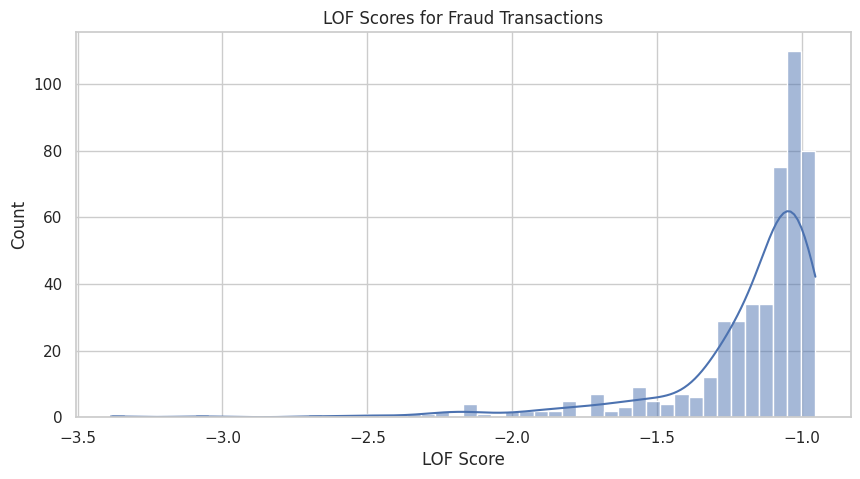

In [67]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df[df['Class'] == 1],
    x='lof_score',
    bins=50,
    kde=True
)

plt.title("LOF Scores for Fraud Transactions")
plt.xlabel("LOF Score")
plt.ylabel("Count")
plt.show()

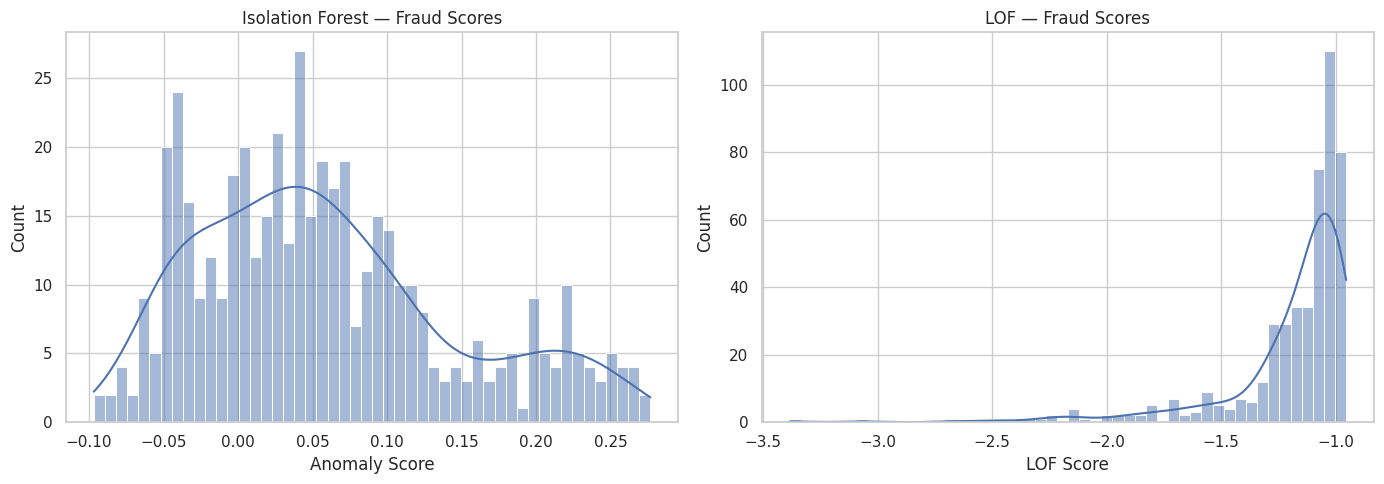

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Isolation Forest
sns.histplot(
    df[df['Class'] == 1]['anomaly_score'],
    bins=50,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Isolation Forest — Fraud Scores")
axes[0].set_xlabel("Anomaly Score")
axes[0].set_ylabel("Count")

# LOF
sns.histplot(
    df[df['Class'] == 1]['lof_score'],
    bins=50,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("LOF — Fraud Scores")
axes[1].set_xlabel("LOF Score")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

*Isolation Forest produced a wider range of scores among fraudulent transactions, with a subset receiving strongly negative anomaly scores. LOF scores were more tightly clustered, indicating that most fraudulent transactions did not appear substantially different from their local neighborhoods. This was reflected in the model evaluation, where Isolation Forest detected 132 of 473 fraud cases, compared with only 1 detected by LOF.*

## Tuning Isolation Forest
Sweeping the `contamination` parameter to find the best precision/recall/F1 trade-off.

### Tuning Isolation Forest

In [69]:
contamination_values = [0.0005, 0.001, 0.0017, 0.0025, 0.005]

results = []

for contamination in contamination_values:

    model = IsolationForest(
        contamination=contamination,
        random_state=42
    )

    predictions = model.fit_predict(X)

    # Convert -1/1 to 1/0
    predictions = (predictions == -1).astype(int)

    precision = precision_score(df['Class'], predictions)
    recall = recall_score(df['Class'], predictions)
    f1 = f1_score(df['Class'], predictions)

    results.append({
        'contamination': contamination,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })

results_df = pd.DataFrame(results)

results_df

,contamination,precision,recall,f1_score
0,0.0005,0.366197,0.109937,0.169106
1,0.0010,0.327465,0.196617,0.245707
2,0.0017,0.273292,0.279070,0.276151
3,0.0025,0.233803,0.350951,0.280642
4,0.0050,0.157153,0.471459,0.235729


*Among the tested contamination values, 0.0025 produced the highest F1-score (0.281), while 0.005 achieved the highest recall (0.471) at the cost of lower precision.*

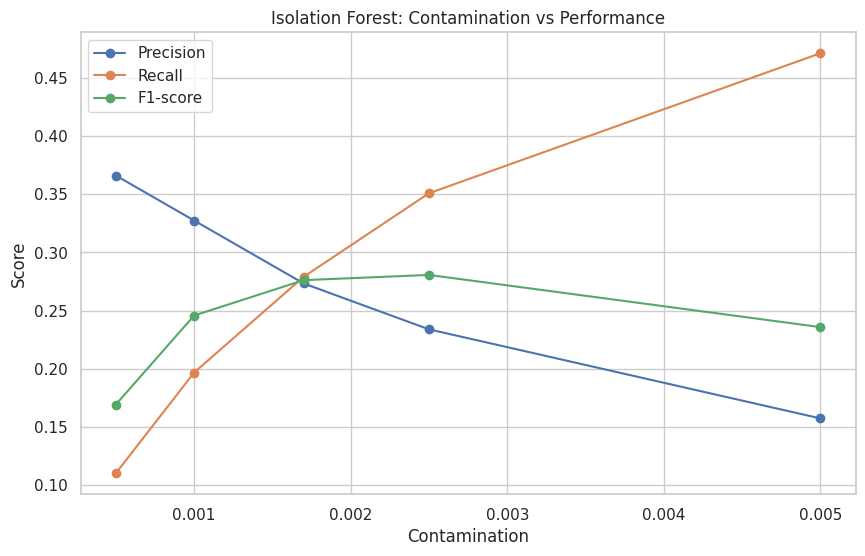

In [70]:
plt.figure(figsize=(10, 6))

plt.plot(
    results_df['contamination'],
    results_df['precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    results_df['contamination'],
    results_df['recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    results_df['contamination'],
    results_df['f1_score'],
    marker='o',
    label='F1-score'
)

plt.xlabel("Contamination")
plt.ylabel("Score")
plt.title("Isolation Forest: Contamination vs Performance")
plt.legend()
plt.grid(True)
plt.show()

### Final Model
Refitting Isolation Forest with the best-performing contamination value.

In [71]:
final_model = IsolationForest(
    contamination=0.0025,
    random_state=42
)

final_predictions = final_model.fit_predict(X)

final_predictions = (final_predictions == -1).astype(int)

In [72]:
print("Precision:", precision_score(df['Class'], final_predictions))
print("Recall:", recall_score(df['Class'], final_predictions))
print("F1-score:", f1_score(df['Class'], final_predictions))

Precision: 0.23380281690140844
Recall: 0.35095137420718814
F1-score: 0.28064243448858833


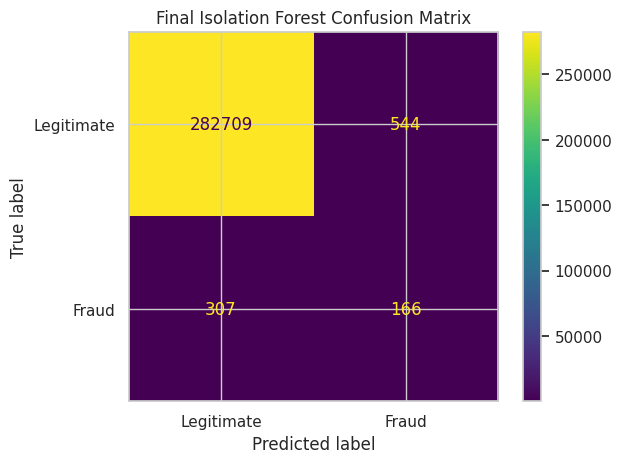

In [73]:
cm = confusion_matrix(df['Class'], final_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Legitimate', 'Fraud']
).plot()

plt.title("Final Isolation Forest Confusion Matrix")
plt.show()

In [74]:
comparison = pd.DataFrame({
    'Model': ['Isolation Forest', 'LOF'],
    'Precision': [0.2338, 0.0021],
    'Recall': [0.3510, 0.0021],
    'F1-score': [0.2806, 0.0021]
})

comparison

,Model,Precision,Recall,F1-score
0,Isolation Forest,0.2338,0.3510,0.2806
1,LOF,0.0021,0.0021,0.0021


## Conclusion

*Isolation Forest captured substantially more fraudulent transactions than LOF in this experiment.*

*LOF identified transactions that were locally unusual, but those unusual transactions had very little overlap with the actual fraud labels. This is an important result. Not every statistical anomaly corresponds to fraud.*